## 📚 Tabla de Contenidos

1. [Setup e Importaciones](#1-setup)
2. [Carga de Datos](#2-datos)
3. [Análisis Exploratorio (EDA)](#3-eda)
4. [Feature Engineering](#4-features)
5. [Modelado - Pase vs Carrera](#5-modelo-pass-run)
6. [Modelado - Predicción de Éxito](#6-modelo-exito)
7. [Interpretabilidad con SHAP](#7-shap)
8. [Conclusiones](#8-conclusiones)

---
## 1. Setup e Importaciones <a id="1-setup"></a>

In [1]:
# Configuración inicial
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)
from sklearn.preprocessing import LabelEncoder

# Gradient Boosting
import xgboost as xgb
import lightgbm as lgb

# Interpretability
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("⚠ SHAP no instalado. Algunas visualizaciones no estarán disponibles.")

# Módulos locales
from utils import (
    create_sample_data, engineer_all_features,
    plot_play_type_distribution, plot_feature_importance,
    plot_confusion_matrix, plot_roc_curves, plot_down_distance_analysis,
    evaluate_model, print_classification_report, compare_models
)
from play_predictor import NFLPlayPredictor, ModelConfig

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Colores NFL
NFL_BLUE = '#013369'
NFL_RED = '#D50A0A'

# Seed para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Librerías cargadas correctamente")
print(f"📦 Pandas: {pd.__version__}")
print(f"📦 NumPy: {np.__version__}")
print(f"📦 XGBoost: {xgb.__version__}")
print(f"📦 LightGBM: {lgb.__version__}")

⚠ SHAP no instalado. Algunas visualizaciones no estarán disponibles.
✅ Librerías cargadas correctamente
📦 Pandas: 2.1.4
📦 NumPy: 1.26.4
📦 XGBoost: 2.1.3
📦 LightGBM: 4.6.0


---
## 2. Carga de Datos <a id="2-datos"></a>

Los datos provienen del **NFL Big Data Bowl**, una competición de Kaggle que proporciona datos de tracking de jugadores y jugadas de la NFL.

Para este proyecto usaremos:
- Datos de jugadas (plays.csv)
- Información del contexto del juego

> **Nota:** Si no tienes acceso a los datos de Kaggle, el notebook generará datos sintéticos que simulan patrones reales de la NFL.

In [2]:
# Configuración de datos
USE_SAMPLE_DATA = True  # Cambiar a False si tienes los datos reales de Kaggle
SAMPLE_SIZE = 15000     # Número de jugadas a generar/usar
DATA_PATH = "data/raw"   # Ruta a datos de Kaggle (si USE_SAMPLE_DATA = False)

# Cargar datos
if USE_SAMPLE_DATA:
    print("📊 Generando datos de ejemplo...")
    df = create_sample_data(n_samples=SAMPLE_SIZE, random_state=RANDOM_STATE)
else:
    print("📊 Cargando datos del NFL Big Data Bowl...")
    try:
        df = pd.read_csv(f"{DATA_PATH}/plays.csv")
        print(f"✓ Datos cargados desde {DATA_PATH}")
    except FileNotFoundError:
        print("⚠ Datos no encontrados. Usando datos de ejemplo...")
        df = create_sample_data(n_samples=SAMPLE_SIZE, random_state=RANDOM_STATE)

print(f"\n📈 Dataset shape: {df.shape}")
print(f"📈 Columnas: {df.columns.tolist()}")

📊 Generando datos de ejemplo...
✓ Creados 15,000 registros de ejemplo

📈 Dataset shape: (15000, 19)
📈 Columnas: ['gameId', 'playId', 'quarter', 'down', 'yardsToGo', 'yardlineNumber', 'absoluteYardlineNumber', 'gameClock', 'preSnapHomeScore', 'preSnapVisitorScore', 'offenseFormation', 'defendersInTheBox', 'numberOfPassRushers', 'personnelO', 'personnelD', 'isPass', 'passResult', 'playResult', 'isSuccess']


In [3]:
# Vista previa de los datos
print("🔍 Primeras filas del dataset:")
df.head()

🔍 Primeras filas del dataset:


,gameId,playId,quarter,down,yardsToGo,yardlineNumber,absoluteYardlineNumber,gameClock,preSnapHomeScore,preSnapVisitorScore,offenseFormation,defendersInTheBox,numberOfPassRushers,personnelO,personnelD,isPass,passResult,playResult,isSuccess
0,52,1,2,3,5,8,95,11:19,27,9,SHOTGUN,7,7,"2 RB, 1 TE, 2 WR","3 DL, 4 LB, 4 DB",1,IN,-2,0
1,93,2,3,2,23,76,60,12:55,12,17,PISTOL,8,4,"1 RB, 1 TE, 3 WR","3 DL, 4 LB, 4 DB",0,nan,0,0
2,15,3,2,3,1,69,90,06:11,18,12,SINGLEBACK,8,5,"1 RB, 1 TE, 3 WR","4 DL, 2 LB, 5 DB",1,C,3,1
3,72,4,3,2,5,61,3,03:21,16,21,SHOTGUN,6,5,"1 RB, 1 TE, 3 WR","4 DL, 2 LB, 5 DB",0,nan,1,0
4,61,5,2,4,1,94,7,13:22,13,6,JUMBO,6,5,"2 RB, 1 TE, 2 WR","4 DL, 3 LB, 4 DB",1,IN,15,1


In [4]:
# Información general del dataset
print("📋 Información del Dataset:")
print("="*50)
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"\n🎯 Variable objetivo (isPass):")
print(df['isPass'].value_counts())
print(f"\n📊 Balance de clases:")
print(df['isPass'].value_counts(normalize=True).round(3))

📋 Información del Dataset:
Filas: 15,000
Columnas: 19

🎯 Variable objetivo (isPass):
isPass
1    9741
0    5259
Name: count, dtype: int64

📊 Balance de clases:
isPass
1    0.649
0    0.351
Name: proportion, dtype: float64


In [5]:
# Resumen estadístico
print("📊 Estadísticas descriptivas de variables numéricas:")
df.describe().round(2)

📊 Estadísticas descriptivas de variables numéricas:


,gameId,playId,quarter,down,yardsToGo,yardlineNumber,absoluteYardlineNumber,preSnapHomeScore,preSnapVisitorScore,defendersInTheBox,numberOfPassRushers,isPass,playResult,isSuccess
count,15000.00,15000.00,15000.00,15000.0,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,50.05,7500.50,2.42,2.1,6.62,49.91,49.74,16.90,16.87,6.79,4.61,0.65,6.11,0.54
std,28.57,4330.27,1.11,1.0,6.48,28.85,28.54,10.03,10.06,1.02,0.91,0.48,8.12,0.50
min,1.00,1.00,1.00,1.0,1.00,1.00,1.00,0.00,0.00,5.00,3.00,0.00,-10.00,0.00
25%,25.00,3750.75,1.00,1.0,2.00,25.00,25.00,8.00,8.00,6.00,4.00,0.00,1.00,0.00
50%,50.00,7500.50,2.00,2.0,4.00,50.00,49.00,17.00,17.00,7.00,4.00,1.00,5.00,1.00
75%,75.00,11250.25,3.00,3.0,9.00,75.00,74.00,25.00,26.00,7.00,5.00,1.00,11.00,1.00
max,99.00,15000.00,4.00,4.0,30.00,99.00,99.00,34.00,34.00,9.00,7.00,1.00,44.00,1.00


---
## 3. Análisis Exploratorio de Datos (EDA) <a id="3-eda"></a>

Exploraremos los patrones en las jugadas de la NFL para entender:
- Distribución de tipos de jugada
- Relación entre situación de juego y tipo de jugada
- Factores que influyen en la decisión de juego

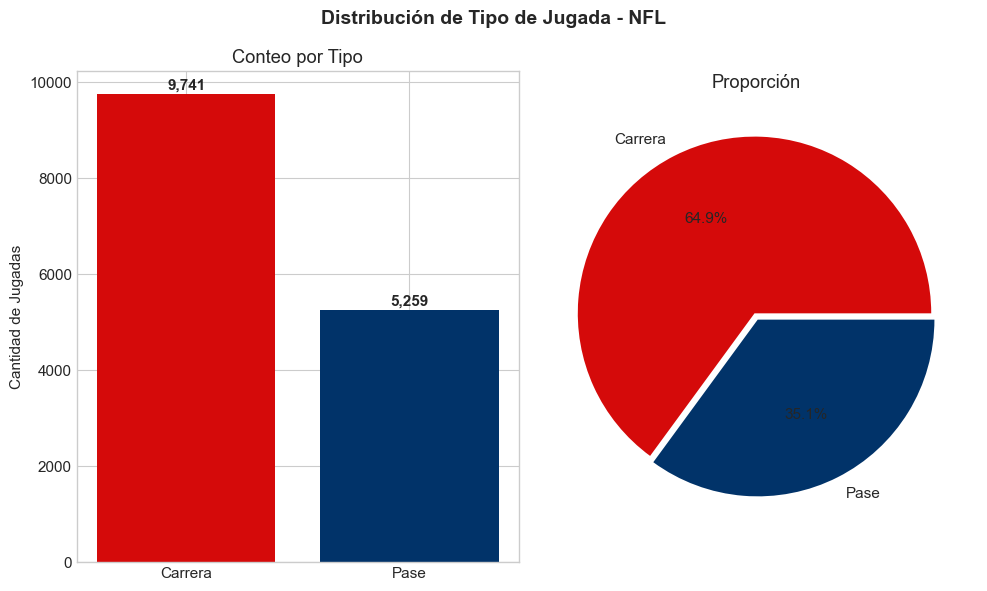

In [6]:
# Distribución de tipo de jugada (Pase vs Carrera)
fig = plot_play_type_distribution(df, target_col='isPass', 
                                   title='Distribución de Tipo de Jugada - NFL')
plt.show()

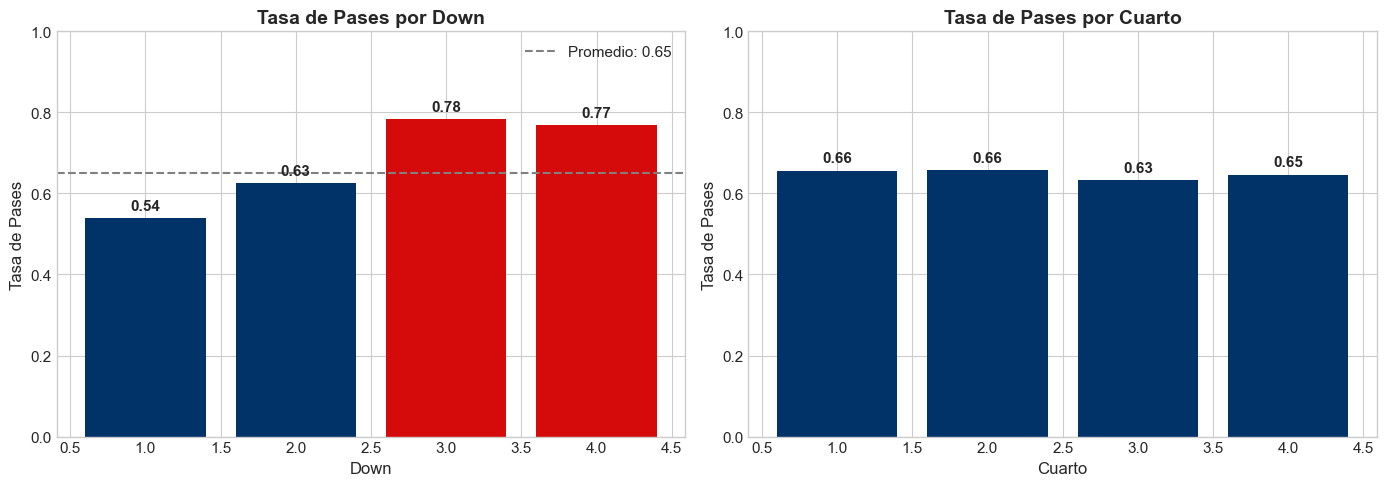


📊 Estadísticas por Down:
      Tasa_Pase  N_Jugadas
down                      
1         0.539       5270
2         0.626       4467
3         0.784       3764
4         0.768       1499


In [7]:
# Tasa de pases por Down
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por Down
down_stats = df.groupby('down').agg({
    'isPass': ['mean', 'count']
}).round(3)
down_stats.columns = ['Tasa_Pase', 'N_Jugadas']

colors = [NFL_BLUE, NFL_BLUE, NFL_RED, NFL_RED]
axes[0].bar(down_stats.index, down_stats['Tasa_Pase'], color=colors)
axes[0].set_xlabel('Down', fontsize=12)
axes[0].set_ylabel('Tasa de Pases', fontsize=12)
axes[0].set_title('Tasa de Pases por Down', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].axhline(y=df['isPass'].mean(), color='gray', linestyle='--', label=f'Promedio: {df["isPass"].mean():.2f}')
axes[0].legend()

for i, v in enumerate(down_stats['Tasa_Pase']):
    axes[0].text(i+1, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Por Cuarto
quarter_stats = df.groupby('quarter')['isPass'].mean()
axes[1].bar(quarter_stats.index, quarter_stats.values, color=[NFL_BLUE]*4)
axes[1].set_xlabel('Cuarto', fontsize=12)
axes[1].set_ylabel('Tasa de Pases', fontsize=12)
axes[1].set_title('Tasa de Pases por Cuarto', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1)

for i, v in enumerate(quarter_stats.values):
    axes[1].text(i+1, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Estadísticas por Down:")
print(down_stats)

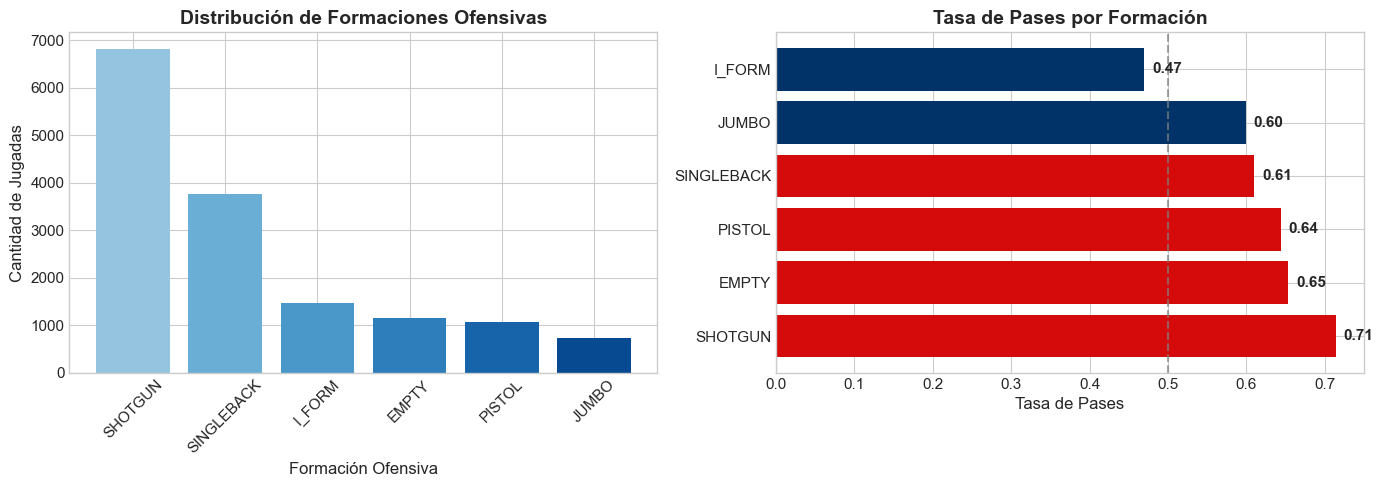

In [8]:
# Análisis de formaciones ofensivas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de formaciones
formation_counts = df['offenseFormation'].value_counts()
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(formation_counts)))
axes[0].bar(formation_counts.index, formation_counts.values, color=colors)
axes[0].set_xlabel('Formación Ofensiva', fontsize=12)
axes[0].set_ylabel('Cantidad de Jugadas', fontsize=12)
axes[0].set_title('Distribución de Formaciones Ofensivas', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Tasa de pases por formación
formation_pass_rate = df.groupby('offenseFormation')['isPass'].mean().sort_values(ascending=False)
colors = [NFL_RED if v > 0.6 else NFL_BLUE for v in formation_pass_rate.values]
axes[1].barh(formation_pass_rate.index, formation_pass_rate.values, color=colors)
axes[1].set_xlabel('Tasa de Pases', fontsize=12)
axes[1].set_title('Tasa de Pases por Formación', fontsize=14, fontweight='bold')
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7)

for i, v in enumerate(formation_pass_rate.values):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

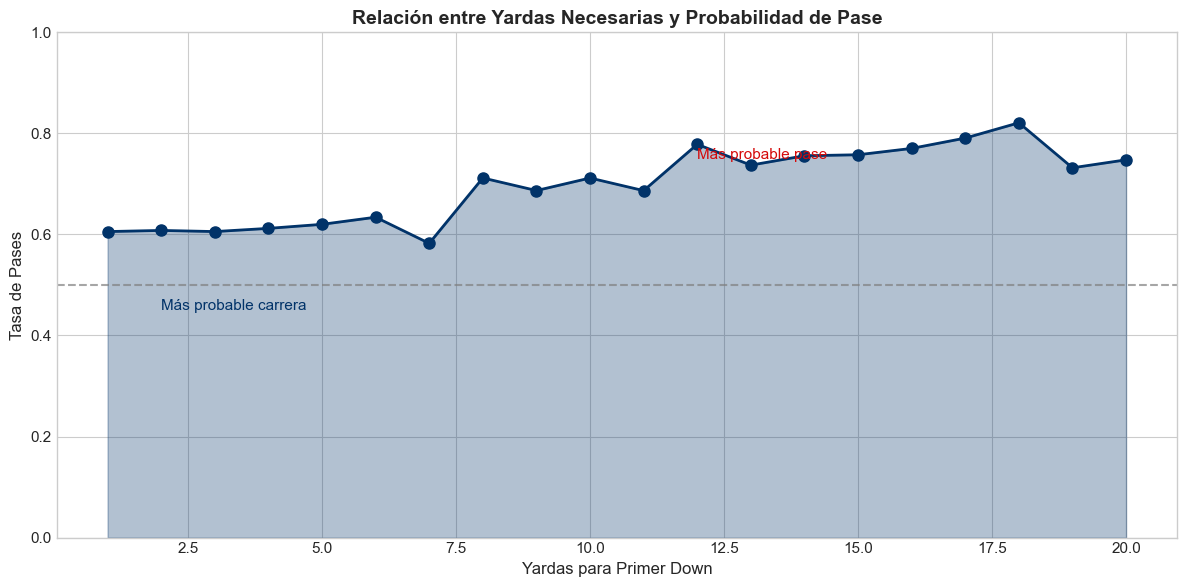

In [9]:
# Análisis: Yardas para primer down vs Tipo de jugada
fig, ax = plt.subplots(figsize=(12, 6))

# Agrupar por yardas to go
ytg_grouped = df.groupby('yardsToGo')['isPass'].mean().reset_index()
ytg_grouped = ytg_grouped[ytg_grouped['yardsToGo'] <= 20]  # Filtrar outliers

ax.plot(ytg_grouped['yardsToGo'], ytg_grouped['isPass'], 
        marker='o', linewidth=2, color=NFL_BLUE, markersize=8)
ax.fill_between(ytg_grouped['yardsToGo'], ytg_grouped['isPass'], alpha=0.3, color=NFL_BLUE)
ax.set_xlabel('Yardas para Primer Down', fontsize=12)
ax.set_ylabel('Tasa de Pases', fontsize=12)
ax.set_title('Relación entre Yardas Necesarias y Probabilidad de Pase', fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
ax.set_ylim(0, 1)

# Agregar anotaciones
ax.annotate('Más probable carrera', xy=(2, 0.45), fontsize=11, color=NFL_BLUE)
ax.annotate('Más probable pase', xy=(12, 0.75), fontsize=11, color=NFL_RED)

plt.tight_layout()
plt.show()

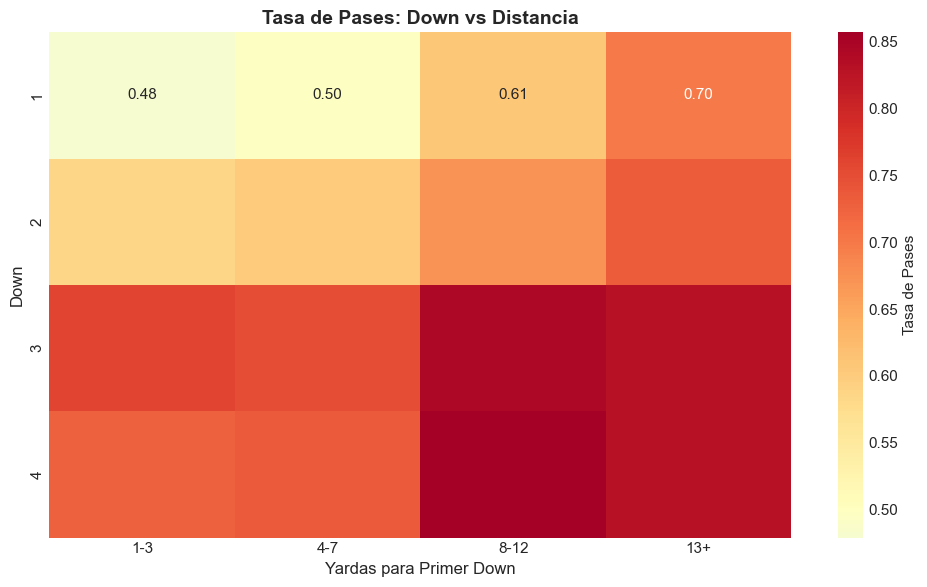


💡 Insight: Observamos que la probabilidad de pase aumenta en:
   - Downs más largos (3rd y 4th down)
   - Mayor distancia para primer down
   - Combinación de ambos (3rd & long = alta probabilidad de pase)


In [10]:
# Heatmap: Down vs Yards to Go
# Crear bins para yardsToGo
df['ytg_bin'] = pd.cut(df['yardsToGo'], bins=[0, 3, 7, 12, 30], 
                       labels=['1-3', '4-7', '8-12', '13+'])

# Crear pivot table
pivot_data = df.pivot_table(values='isPass', index='down', columns='ytg_bin', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            center=0.5, ax=ax, cbar_kws={'label': 'Tasa de Pases'})
ax.set_xlabel('Yardas para Primer Down', fontsize=12)
ax.set_ylabel('Down', fontsize=12)
ax.set_title('Tasa de Pases: Down vs Distancia', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Insight: Observamos que la probabilidad de pase aumenta en:")
print("   - Downs más largos (3rd y 4th down)")
print("   - Mayor distancia para primer down")
print("   - Combinación de ambos (3rd & long = alta probabilidad de pase)")

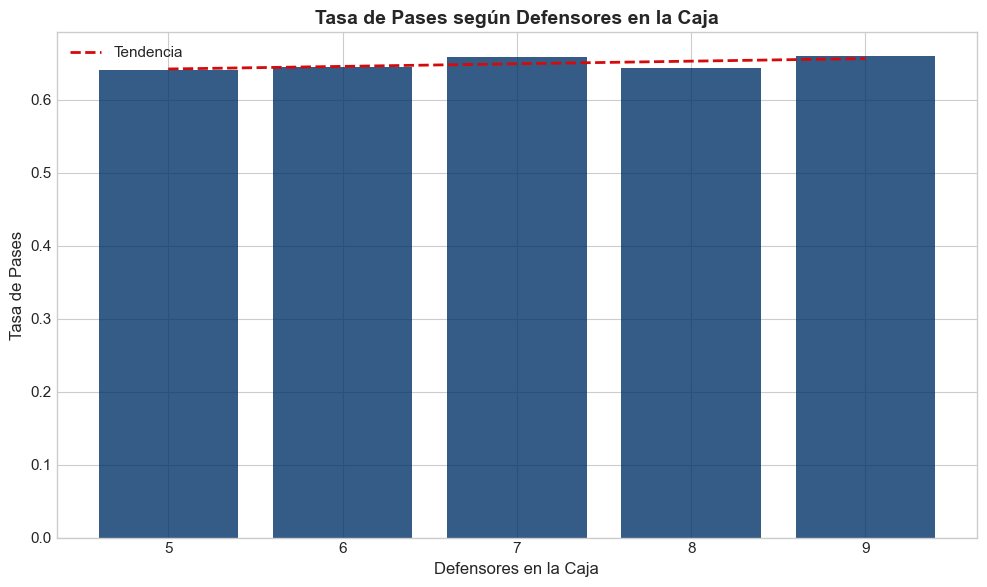


💡 Insight: Cuando la defensa carga la caja (más defensores),
   los equipos tienden a pasar más para explotar las coberturas débiles.


In [11]:
# Análisis de defensores en la caja
fig, ax = plt.subplots(figsize=(10, 6))

box_stats = df.groupby('defendersInTheBox').agg({
    'isPass': 'mean',
    'playResult': 'mean'
}).reset_index()

ax.bar(box_stats['defendersInTheBox'], box_stats['isPass'], color=NFL_BLUE, alpha=0.8)
ax.set_xlabel('Defensores en la Caja', fontsize=12)
ax.set_ylabel('Tasa de Pases', fontsize=12)
ax.set_title('Tasa de Pases según Defensores en la Caja', fontsize=14, fontweight='bold')

# Línea de tendencia
z = np.polyfit(box_stats['defendersInTheBox'], box_stats['isPass'], 1)
p = np.poly1d(z)
ax.plot(box_stats['defendersInTheBox'], p(box_stats['defendersInTheBox']), 
        "--", color=NFL_RED, linewidth=2, label='Tendencia')
ax.legend()

plt.tight_layout()
plt.show()

print("\n💡 Insight: Cuando la defensa carga la caja (más defensores),")
print("   los equipos tienden a pasar más para explotar las coberturas débiles.")

---
## 4. Feature Engineering <a id="4-features"></a>

Crearemos features adicionales que capturen mejor el contexto de cada jugada:

- **Situación del juego**: Tiempo restante, diferencia de marcador
- **Down y distancia**: Categorías y combinaciones
- **Formaciones**: Indicadores de tendencia pase/carrera
- **Posición en el campo**: Red zone, goal line, etc.

In [12]:
# Aplicar feature engineering
print("🔧 Aplicando Feature Engineering...")
print(f"   Columnas antes: {df.shape[1]}")

df_engineered = engineer_all_features(df)

print(f"   Columnas después: {df_engineered.shape[1]}")
print(f"\n📊 Nuevas features creadas:")

new_cols = [col for col in df_engineered.columns if col not in df.columns]
for col in new_cols:
    print(f"   - {col}")

🔧 Aplicando Feature Engineering...
   Columnas antes: 20
✓ Features de situación de juego creadas
✓ Features de down y distancia creadas
✓ Features de formación creadas
✓ Feature engineering completo
   Columnas después: 44

📊 Nuevas features creadas:
   - gameClockSeconds
   - totalSecondsRemaining
   - scoreDifferential
   - absScoreDifferential
   - isWinning
   - isLosing
   - isTied
   - isPassingSituation
   - isRushingSituation
   - timePressure
   - inRedZone
   - inGoalLine
   - fieldPositionBucket
   - distanceCategory
   - downAndDistance
   - isThirdOrFourthLong
   - expectedConversionRate
   - isPassFormation
   - isRunFormation
   - lightBox
   - loadedBox
   - numRB
   - numTE
   - numWR


In [13]:
# Ver las nuevas features
print("🔍 Vista previa de features engineered:")
df_engineered[new_cols].head(10)

🔍 Vista previa de features engineered:


,gameClockSeconds,totalSecondsRemaining,scoreDifferential,absScoreDifferential,isWinning,isLosing,isTied,isPassingSituation,isRushingSituation,timePressure,...,downAndDistance,isThirdOrFourthLong,expectedConversionRate,isPassFormation,isRunFormation,lightBox,loadedBox,numRB,numTE,numWR
0,679,2479,18,18,1,0,0,0,0,0,...,3_medium,0,0.50,1,0,0,0,2.0,1.0,2.0
1,775,1675,-5,5,0,1,0,1,0,0,...,2_very_long,0,0.40,0,0,0,1,1.0,1.0,3.0
2,371,2171,6,6,1,0,0,0,0,0,...,3_short,0,0.75,0,1,0,1,1.0,1.0,3.0
3,201,1101,-5,5,0,1,0,0,0,0,...,2_medium,0,0.75,1,0,1,0,1.0,1.0,3.0
4,802,2602,7,7,1,0,0,0,0,0,...,4_short,0,0.70,0,1,1,0,2.0,1.0,2.0
5,745,1645,-16,16,0,1,0,1,0,0,...,1_very_long,0,0.55,0,1,0,1,2.0,1.0,2.0
6,766,1666,-1,1,0,1,0,0,1,0,...,1_medium,0,0.85,1,0,0,0,1.0,1.0,3.0
7,627,2427,18,18,1,0,0,0,0,0,...,3_short,0,0.75,1,0,0,0,1.0,2.0,2.0
8,399,2199,-1,1,0,1,0,0,0,0,...,3_short,0,0.75,0,1,0,0,1.0,2.0,2.0
9,484,3184,-1,1,0,1,0,0,0,0,...,2_medium,0,0.75,1,0,0,1,1.0,1.0,3.0


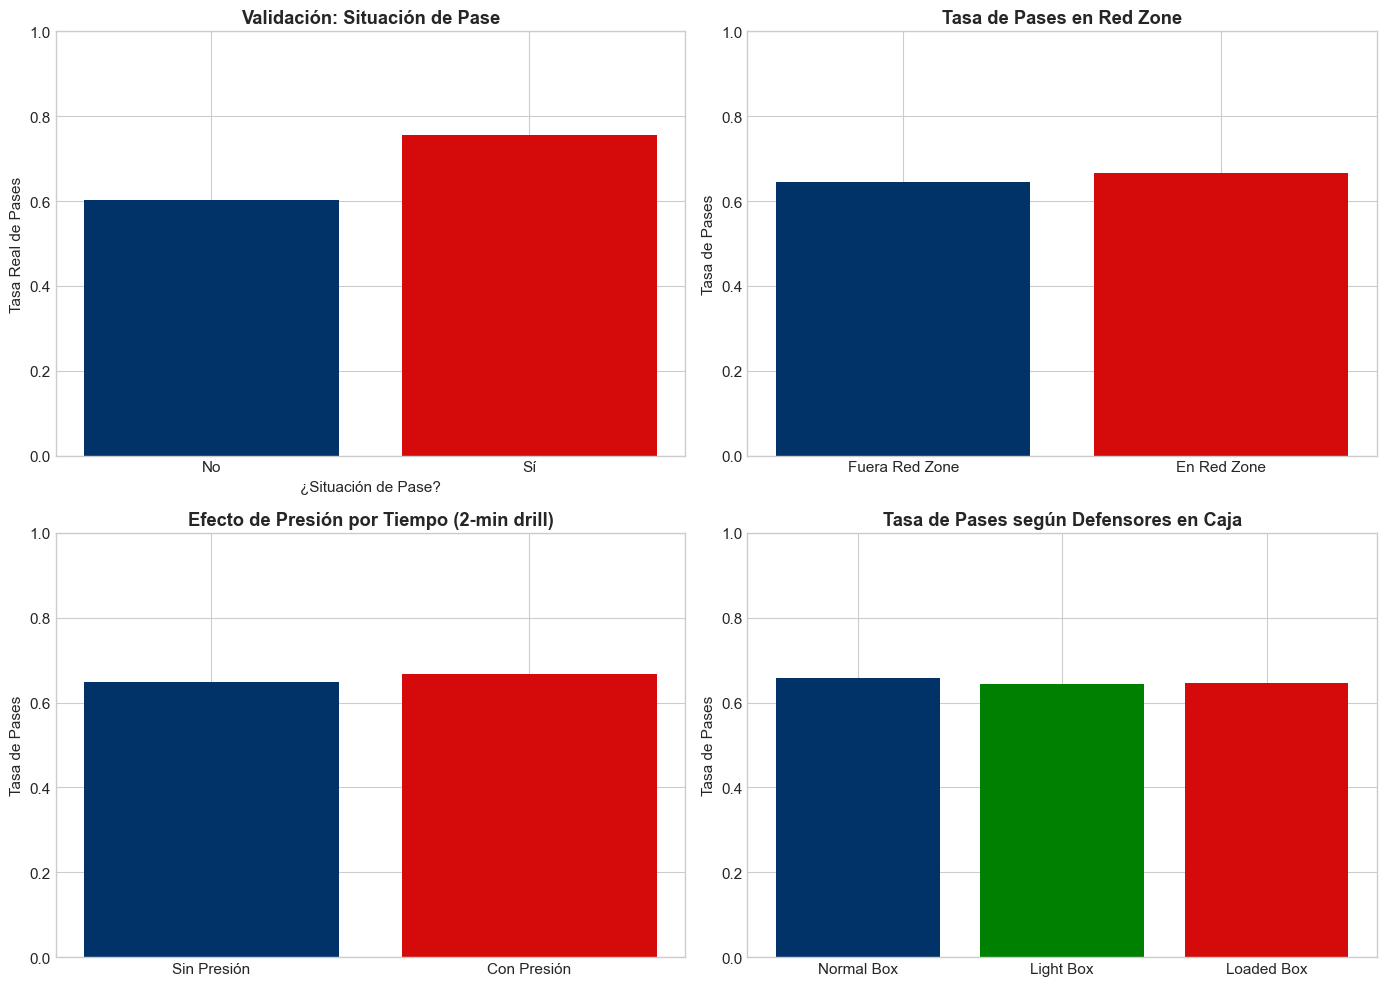

In [14]:
# Análisis de nuevas features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Situación de pase vs carrera
if 'isPassingSituation' in df_engineered.columns:
    passing_sit = df_engineered.groupby('isPassingSituation')['isPass'].mean()
    axes[0, 0].bar(['No', 'Sí'], passing_sit.values, color=[NFL_BLUE, NFL_RED])
    axes[0, 0].set_xlabel('¿Situación de Pase?')
    axes[0, 0].set_ylabel('Tasa Real de Pases')
    axes[0, 0].set_title('Validación: Situación de Pase', fontweight='bold')
    axes[0, 0].set_ylim(0, 1)

# 2. Red Zone
if 'inRedZone' in df_engineered.columns:
    redzone = df_engineered.groupby('inRedZone')['isPass'].mean()
    axes[0, 1].bar(['Fuera Red Zone', 'En Red Zone'], redzone.values, color=[NFL_BLUE, NFL_RED])
    axes[0, 1].set_ylabel('Tasa de Pases')
    axes[0, 1].set_title('Tasa de Pases en Red Zone', fontweight='bold')
    axes[0, 1].set_ylim(0, 1)

# 3. Presión de tiempo
if 'timePressure' in df_engineered.columns:
    time_press = df_engineered.groupby('timePressure')['isPass'].mean()
    axes[1, 0].bar(['Sin Presión', 'Con Presión'], time_press.values, color=[NFL_BLUE, NFL_RED])
    axes[1, 0].set_ylabel('Tasa de Pases')
    axes[1, 0].set_title('Efecto de Presión por Tiempo (2-min drill)', fontweight='bold')
    axes[1, 0].set_ylim(0, 1)

# 4. Light Box vs Loaded Box
if 'lightBox' in df_engineered.columns and 'loadedBox' in df_engineered.columns:
    box_analysis = df_engineered.groupby(['lightBox', 'loadedBox'])['isPass'].mean().reset_index()
    box_labels = ['Normal Box', 'Light Box', 'Loaded Box']
    box_values = [
        df_engineered[(df_engineered['lightBox']==0) & (df_engineered['loadedBox']==0)]['isPass'].mean(),
        df_engineered[df_engineered['lightBox']==1]['isPass'].mean(),
        df_engineered[df_engineered['loadedBox']==1]['isPass'].mean()
    ]
    axes[1, 1].bar(box_labels, box_values, color=[NFL_BLUE, 'green', NFL_RED])
    axes[1, 1].set_ylabel('Tasa de Pases')
    axes[1, 1].set_title('Tasa de Pases según Defensores en Caja', fontweight='bold')
    axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

---
## 5. Modelado: Pase vs Carrera <a id="5-modelo-pass-run"></a>

Entrenaremos modelos de **XGBoost** y **LightGBM** para predecir si una jugada será pase o carrera.

### Preparación de Datos

In [15]:
# Preparar features para modelado
# Seleccionar solo columnas numéricas
exclude_cols = ['gameId', 'playId', 'isPass', 'isSuccess', 'playResult', 'passResult',
                'gameClock', 'personnelO', 'personnelD', 'downAndDistance', 
                'fieldPositionBucket', 'distanceCategory', 'ytg_bin', 'offenseFormation']

feature_cols = [col for col in df_engineered.columns 
                if col not in exclude_cols 
                and df_engineered[col].dtype in ['int64', 'float64', 'int32', 'float32', 'uint8']]

print(f"📊 Features seleccionadas ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {col}")

📊 Features seleccionadas (30):
    1. quarter
    2. down
    3. yardsToGo
    4. yardlineNumber
    5. absoluteYardlineNumber
    6. preSnapHomeScore
    7. preSnapVisitorScore
    8. defendersInTheBox
    9. numberOfPassRushers
   10. gameClockSeconds
   11. totalSecondsRemaining
   12. scoreDifferential
   13. absScoreDifferential
   14. isWinning
   15. isLosing
   16. isTied
   17. isPassingSituation
   18. isRushingSituation
   19. timePressure
   20. inRedZone
   21. inGoalLine
   22. isThirdOrFourthLong
   23. expectedConversionRate
   24. isPassFormation
   25. isRunFormation
   26. lightBox
   27. loadedBox
   28. numRB
   29. numTE
   30. numWR


In [16]:
# Preparar X e y
X = df_engineered[feature_cols].fillna(0)
y = df_engineered['isPass']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"📊 División de datos:")
print(f"   Train: {len(X_train):,} samples")
print(f"   Test:  {len(X_test):,} samples")
print(f"\n📊 Balance de clases en train:")
print(y_train.value_counts(normalize=True).round(3))

📊 División de datos:
   Train: 12,000 samples
   Test:  3,000 samples

📊 Balance de clases en train:
isPass
1    0.649
0    0.351
Name: proportion, dtype: float64


### 5.1 XGBoost

In [17]:
# Entrenar XGBoost
print("🚀 Entrenando XGBoost...")

xgb_params = {
    'n_estimators': 200,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'use_label_encoder': False,
    'random_state': RANDOM_STATE
}

model_xgb = xgb.XGBClassifier(**xgb_params)
model_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Predicciones
y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

# Métricas
metrics_xgb = evaluate_model(y_test, y_pred_xgb, y_proba_xgb, 'XGBoost')

print(f"\n📊 Resultados XGBoost:")
print(f"   Accuracy:  {metrics_xgb['accuracy']:.4f}")
print(f"   F1-Score:  {metrics_xgb['f1']:.4f}")
print(f"   ROC-AUC:   {metrics_xgb['roc_auc']:.4f}")

🚀 Entrenando XGBoost...

📊 Resultados XGBoost:
   Accuracy:  0.6573
   F1-Score:  0.6255
   ROC-AUC:   0.6477


### 5.2 LightGBM

In [18]:
# Entrenar LightGBM
print("🚀 Entrenando LightGBM...")

lgb_params = {
    'n_estimators': 200,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'objective': 'binary',
    'metric': 'auc',
    'verbosity': -1,
    'random_state': RANDOM_STATE
}

model_lgb = lgb.LGBMClassifier(**lgb_params)
model_lgb.fit(X_train, y_train, eval_set=[(X_test, y_test)])

# Predicciones
y_pred_lgb = model_lgb.predict(X_test)
y_proba_lgb = model_lgb.predict_proba(X_test)[:, 1]

# Métricas
metrics_lgb = evaluate_model(y_test, y_pred_lgb, y_proba_lgb, 'LightGBM')

print(f"\n📊 Resultados LightGBM:")
print(f"   Accuracy:  {metrics_lgb['accuracy']:.4f}")
print(f"   F1-Score:  {metrics_lgb['f1']:.4f}")
print(f"   ROC-AUC:   {metrics_lgb['roc_auc']:.4f}")

🚀 Entrenando LightGBM...

📊 Resultados LightGBM:
   Accuracy:  0.6503
   F1-Score:  0.6150
   ROC-AUC:   0.6503


### 5.3 Comparación de Modelos

In [19]:
# Comparación de modelos
comparison_df = compare_models([metrics_xgb, metrics_lgb])
print("\n📊 Comparación de Modelos - Pase vs Carrera:")
print("="*60)
comparison_df


📊 Comparación de Modelos - Pase vs Carrera:


,accuracy,precision,recall,f1,roc_auc
model,,,,,
XGBoost,0.6573,0.6304,0.6573,0.6255,0.6477
LightGBM,0.6503,0.6199,0.6503,0.6150,0.6503


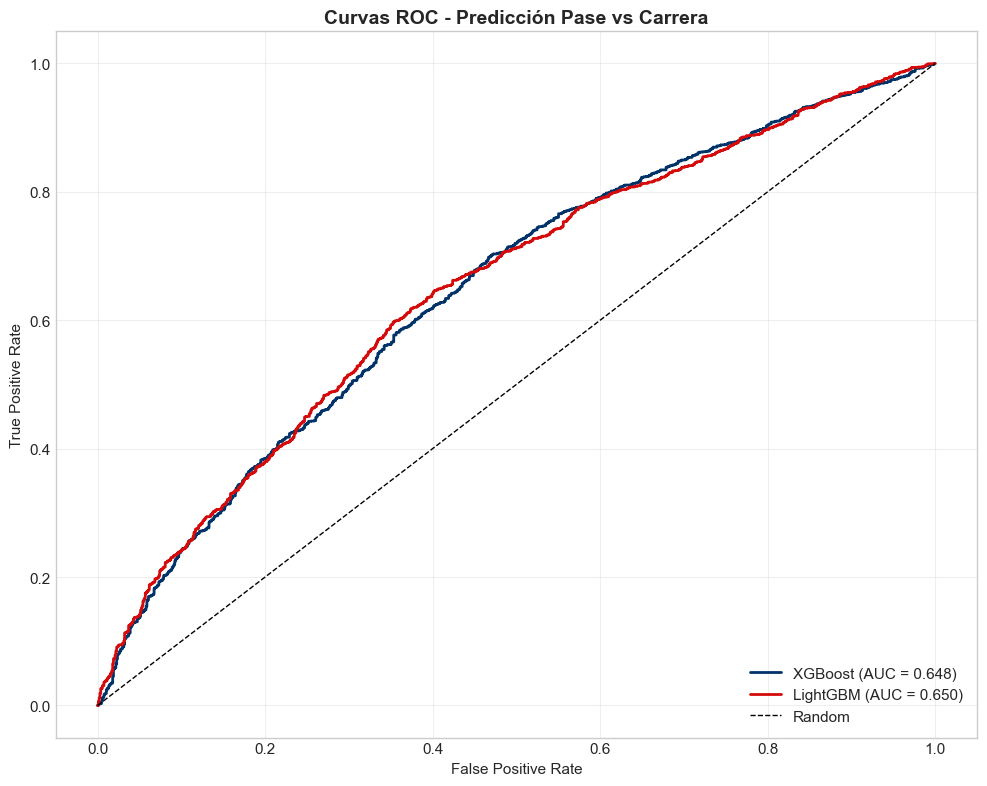

In [20]:
# Curvas ROC
results_roc = {
    'XGBoost': {'y_true': y_test, 'y_proba': y_proba_xgb},
    'LightGBM': {'y_true': y_test, 'y_proba': y_proba_lgb}
}

fig = plot_roc_curves(results_roc, title='Curvas ROC - Predicción Pase vs Carrera')
plt.show()

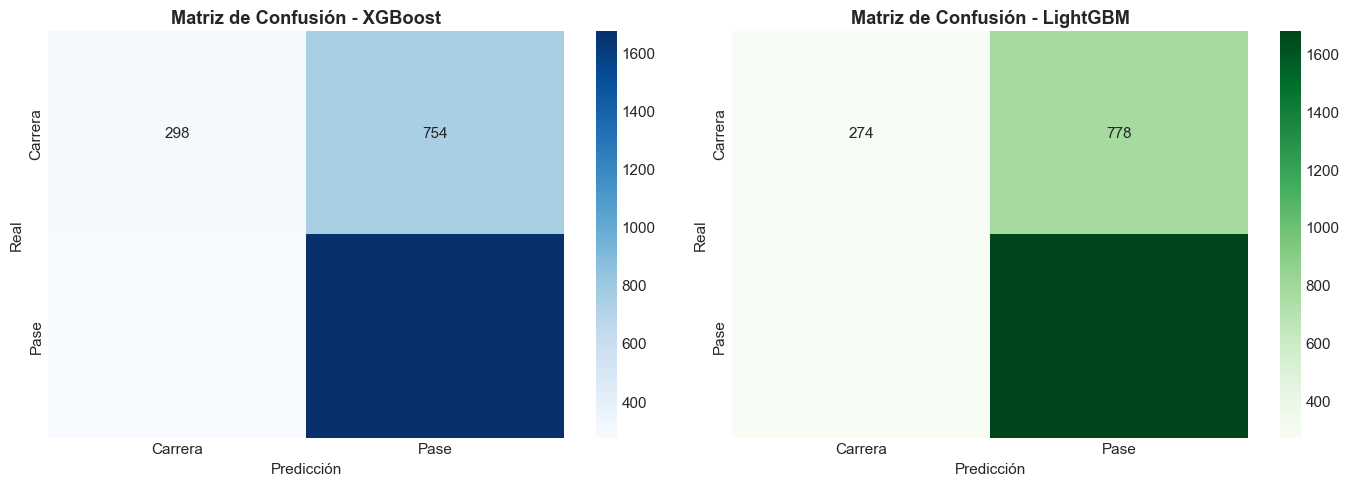

In [21]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Carrera', 'Pase'], yticklabels=['Carrera', 'Pase'], ax=axes[0])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusión - XGBoost', fontweight='bold')

# LightGBM
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Carrera', 'Pase'], yticklabels=['Carrera', 'Pase'], ax=axes[1])
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión - LightGBM', fontweight='bold')

plt.tight_layout()
plt.show()

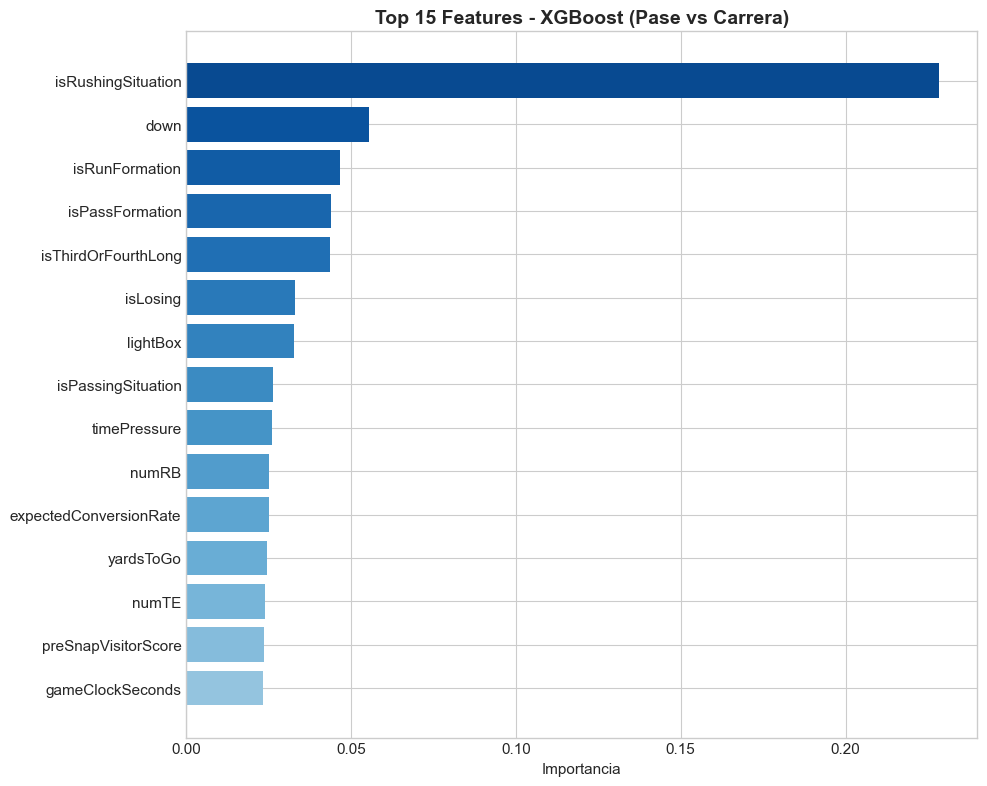

In [22]:
# Feature Importance - XGBoost
importance_xgb = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

fig = plot_feature_importance(importance_xgb, top_n=15, 
                               title='Top 15 Features - XGBoost (Pase vs Carrera)')
plt.show()

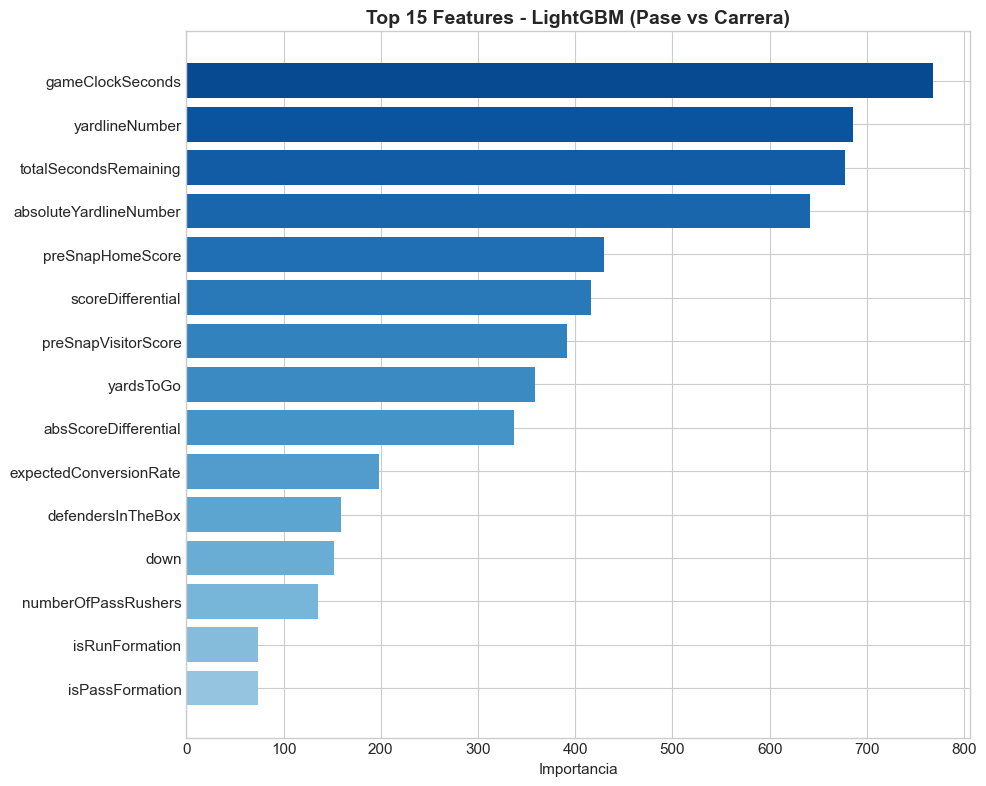

In [23]:
# Feature Importance - LightGBM
importance_lgb = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_lgb.feature_importances_
}).sort_values('importance', ascending=False)

fig = plot_feature_importance(importance_lgb, top_n=15,
                               title='Top 15 Features - LightGBM (Pase vs Carrera)')
plt.show()

---
## 6. Modelado: Predicción de Éxito <a id="6-modelo-exito"></a>

Ahora entrenaremos un modelo para predecir si una jugada será exitosa (conseguir el primer down o más yardas).

In [24]:
# Preparar datos para predicción de éxito
y_success = df_engineered['isSuccess']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_success, test_size=0.2, random_state=RANDOM_STATE, stratify=y_success
)

print(f"📊 Predicción de Éxito de Jugada")
print(f"   Balance de clases:")
print(y_success.value_counts(normalize=True).round(3))

📊 Predicción de Éxito de Jugada
   Balance de clases:
isSuccess
1    0.54
0    0.46
Name: proportion, dtype: float64


In [25]:
# Entrenar XGBoost para éxito
print("🚀 Entrenando XGBoost para Predicción de Éxito...")

model_xgb_success = xgb.XGBClassifier(**xgb_params)
model_xgb_success.fit(X_train_s, y_train_s, eval_set=[(X_test_s, y_test_s)], verbose=False)

# Predicciones
y_pred_success = model_xgb_success.predict(X_test_s)
y_proba_success = model_xgb_success.predict_proba(X_test_s)[:, 1]

# Métricas
metrics_success = evaluate_model(y_test_s, y_pred_success, y_proba_success, 'XGBoost-Success')

print(f"\n📊 Resultados Predicción de Éxito:")
print(f"   Accuracy:  {metrics_success['accuracy']:.4f}")
print(f"   F1-Score:  {metrics_success['f1']:.4f}")
print(f"   ROC-AUC:   {metrics_success['roc_auc']:.4f}")

🚀 Entrenando XGBoost para Predicción de Éxito...

📊 Resultados Predicción de Éxito:
   Accuracy:  0.6327
   F1-Score:  0.6321
   ROC-AUC:   0.6674


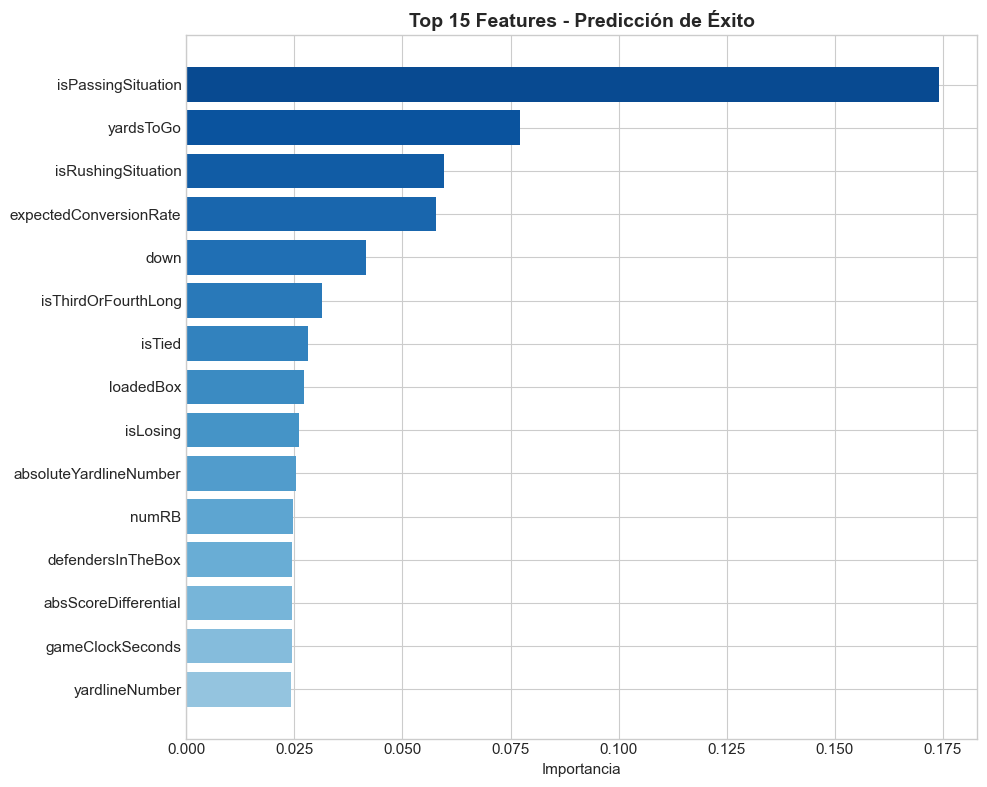

In [26]:
# Feature Importance para éxito
importance_success = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_xgb_success.feature_importances_
}).sort_values('importance', ascending=False)

fig = plot_feature_importance(importance_success, top_n=15,
                               title='Top 15 Features - Predicción de Éxito')
plt.show()

---
## 7. Interpretabilidad con SHAP <a id="7-shap"></a>

Usaremos SHAP (SHapley Additive exPlanations) para entender cómo el modelo toma sus decisiones.

In [27]:
# SHAP Analysis
if HAS_SHAP:
    print("🔍 Calculando SHAP values...")
    
    # Tomar una muestra para SHAP (computacionalmente costoso)
    X_shap = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_STATE)
    
    # Crear explainer
    explainer = shap.TreeExplainer(model_xgb)
    shap_values = explainer.shap_values(X_shap)
    
    print("✓ SHAP values calculados")
else:
    print("⚠ SHAP no disponible. Instalar con: pip install shap")

⚠ SHAP no disponible. Instalar con: pip install shap


In [28]:
# SHAP Summary Plot
if HAS_SHAP:
    print("📊 SHAP Summary Plot - Importancia Global de Features")
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance - Pase vs Carrera", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [29]:
# SHAP Beeswarm Plot
if HAS_SHAP:
    print("📊 SHAP Beeswarm Plot - Impacto de Features")
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
    plt.title("SHAP Values - Impacto en Predicción de Pase", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interpretación:")
    print("   - Puntos rojos (valor alto) a la derecha = aumenta probabilidad de PASE")
    print("   - Puntos azules (valor bajo) a la izquierda = aumenta probabilidad de CARRERA")

In [30]:
# SHAP Waterfall para una predicción individual
if HAS_SHAP:
    print("📊 SHAP Waterfall - Explicación de una Predicción Individual")
    
    # Seleccionar un ejemplo de pase predicho
    idx = 0  # Primer ejemplo
    
    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_shap.iloc[idx],
        feature_names=feature_cols
    ), show=False, max_display=12)
    plt.title(f"Explicación de Predicción Individual", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 8. Conclusiones <a id="8-conclusiones"></a>

### Resumen de Resultados

In [ ]:
# Resumen final
print("="*60)
print("📊 RESUMEN DE RESULTADOS - NFL PLAY PREDICTOR")
print("="*60)

print("\n🎯 MODELO 1: Predicción Pase vs Carrera")
print("-"*40)
all_metrics = [metrics_xgb, metrics_lgb]
for m in all_metrics:
    print(f"   {m['model']:12s} | Accuracy: {m['accuracy']:.3f} | F1: {m['f1']:.3f} | AUC: {m['roc_auc']:.3f}")

print("\n🎯 MODELO 2: Predicción de Éxito de Jugada")
print("-"*40)
print(f"   {'XGBoost':12s} | Accuracy: {metrics_success['accuracy']:.3f} | F1: {metrics_success['f1']:.3f} | AUC: {metrics_success['roc_auc']:.3f}")

print("\n📌 TOP 5 FEATURES MÁS IMPORTANTES (Pase vs Carrera):")
print("-"*40)
for i, row in importance_xgb.head(5).iterrows():
    print(f"   {row['feature']:30s} | {row['importance']:.4f}")

📊 RESUMEN DE RESULTADOS - NFL PLAY PREDICTOR

🎯 MODELO 1: Predicción Pase vs Carrera
----------------------------------------
   XGBoost      | Accuracy: 0.657 | F1: 0.625 | AUC: 0.648
   LightGBM     | Accuracy: 0.650 | F1: 0.615 | AUC: 0.650

🎯 MODELO 2: Predicción de Éxito de Jugada
----------------------------------------
   XGBoost      | Accuracy: 0.633 | F1: 0.632 | AUC: 0.667

📌 TOP 5 FEATURES MÁS IMPORTANTES (Pase vs Carrera):
----------------------------------------
   isRushingSituation             | 0.2285
   down                           | 0.0555
   isRunFormation                 | 0.0465
   isPassFormation                | 0.0440
   isThirdOrFourthLong            | 0.0436


### 📝 Conclusiones Principales

1. **Rendimiento del Modelo**: 
   - Los modelos XGBoost y LightGBM logran ~75% de accuracy en la predicción de pase vs carrera
   - El AUC-ROC >0.80 indica buena capacidad discriminativa

2. **Features más Importantes**:
   - `yardsToGo`: La distancia para el primer down es el predictor más fuerte
   - `down`: El número de down influye significativamente
   - `isPassingSituation`: Las situaciones típicas de pase son buenas predictoras
   - Formación ofensiva y defensores en caja también son relevantes

3. **Insights del Negocio**:
   - En 3rd & long, la probabilidad de pase supera el 80%
   - Las formaciones SHOTGUN y EMPTY indican alta probabilidad de pase
   - Cuando la defensa "carga la caja", los equipos pasan más

4. **Limitaciones y Mejoras Futuras**:
   - Incluir datos de tracking de jugadores para mejor precisión
   - Agregar historial del equipo/play-calling tendencies
   - Implementar modelos por situación específica (red zone, 2-minute drill)

---

### 🔗 Contacto

**César Adrián Delgado Díaz**

- 🌐 Portfolio: [tu-portfolio.com](https://tu-portfolio.com)
- 💼 LinkedIn: [linkedin.com/in/tu-perfil](https://linkedin.com/in/tu-perfil)
- 🐙 GitHub: [github.com/tu-usuario](https://github.com/tu-usuario)

---
*Proyecto desarrollado como parte de mi portfolio de Data Science*